Financial Analytics & Real Estate Market Intelligence  

Real estate companies serve a highly diverse buyer base: individual home buyers, first-time buyers, corporate and institutional investors, international buyers, and high-net-worth investors. When all of these are treated the same, the result is inefficient marketing spend, generic property recommendations, and missed investment opportunities.

- Business motivation:
  - Improve customer targeting
  - Reduce inefficient marketing spend
  - Provide better property recommendations
  - Improve investor targeting
  - Identify missed investment opportunities
- Background:
  - Real estate buyers have diverse characteristics and motivations
  - Major buyer categories include individual buyers, institutional investors,
    international buyers, high-net-worth investors, and first-time buyers
- Role of AI:
  - Use machine learning clustering techniques to discover hidden patterns
    in buyer behavior
  - Group customers into meaningful buyer segments



Project Initialization

In [3]:
#import libraries

import numpy as np
import pandas as pd
import time

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
print(sklearn.__version__)

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score


import os
os.makedirs("../visualizations", exist_ok=True)


1.5.0


Import Data and Create Dataframe

First Dataset : clients.csv

Second Dataset : properties.csv

In [4]:
client = pd.read_csv("C:/Users/Chandan/Desktop/Financial-Analytics-Real-Estate/data/raw/clients.csv")
properties = pd.read_csv("C:/Users/Chandan/Desktop/Financial-Analytics-Real-Estate/data/raw/properties.csv")

In [5]:
client

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C1996,Individual,Samantha,Brooks,6/20/1992,F,USA,Nevada,Home,1,Yes,Website
1996,C1997,Individual,Matthew,Cox,9/27/1942,M,USA,Arizona,Home,4,Yes,Website
1997,C1998,Individual,Mark,Patterson,9/13/1963,M,USA,Virginia,Home,5,Yes,Website
1998,C1999,Individual,Lawrence,Montgomery,6/15/1944,M,USA,Ohio,Home,4,Yes,Client


In [6]:
properties

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146
...,...,...,...,...,...,...,...,...,...
9995,200417,20,12-01-2025,Apartment,48,860.80,"$271,177.34",Available,NaN
9996,200429,20,12-01-2025,Apartment,48,860.80,"$265,186.67",Sold,C1412
9997,200430,20,12-01-2025,Apartment,48,860.80,"$288,189.74",Sold,C0504
9998,200449,20,12-01-2025,Apartment,51,1062.33,"$328,980.19",Available,NaN


In [7]:
client.head(3)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency


In [8]:
client.sample()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
591,C0592,Individual,Roger,Moore,03-06-1972,M,USA,Arizona,Investment,2,No,Client


In [9]:
client.shape

(2000, 12)

In [10]:
client.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

Data Cleaning

In [11]:
client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [12]:
#Changing the data type of the date_of_birth

client['date_of_birth'] = pd.to_datetime(client['date_of_birth'], format='mixed', errors='coerce')

In [13]:
client.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   client_id            2000 non-null   object        
 1   client_type          2000 non-null   object        
 2   first_name           2000 non-null   object        
 3   last_name            2000 non-null   object        
 4   date_of_birth        2000 non-null   datetime64[ns]
 5   gender               2000 non-null   object        
 6   country              2000 non-null   object        
 7   region               2000 non-null   object        
 8   acquisition_purpose  2000 non-null   object        
 9   satisfaction_score   2000 non-null   int64         
 10  loan_applied         2000 non-null   object        
 11  referral_channel     2000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 187.6+ KB


In [14]:
client.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [15]:
client.duplicated(['client_id']).sum()

0

In [16]:
cat_cols = client.columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(client[col].value_counts(dropna=False))


--- client_id ---
client_id
C0001    1
C1330    1
C1343    1
C1342    1
C1341    1
        ..
C0662    1
C0661    1
C0660    1
C0659    1
C2000    1
Name: count, Length: 2000, dtype: int64

--- client_type ---
client_type
Individual    1897
Company        103
Name: count, dtype: int64

--- first_name ---
first_name
Carl       24
Gerald     20
Jason      19
Sarah      19
William    19
           ..
Laurel      1
Simon       1
Aniyah      1
Kamden      1
Kareem      1
Name: count, Length: 337, dtype: int64

--- last_name ---
last_name
Co         103
Howard      39
Hansen      34
Morales     34
Cox         33
          ... 
Larsen       1
Stein        1
Perry        1
Mueller      1
Bailey       1
Name: count, Length: 224, dtype: int64

--- date_of_birth ---
date_of_birth
1993-06-14    3
1975-03-27    3
1973-10-24    3
1967-04-13    3
1995-11-12    3
             ..
1948-08-20    1
1977-04-25    1
1965-04-16    1
1964-12-02    1
1944-06-15    1
Name: count, Length: 1889, dtype: int64

--

In [17]:
for col in cat_cols:
    client[col] = (
        client[col]
        .astype(str)                              # avoid errors on NaN/non-strings
        .str.strip()                              # remove leading/trailing spaces
        .str.lower()                              # consistent case
        .str.replace(r"\s+", " ", regex=True)     # collapse multiple spaces
        .str.replace(r"[_\-]+", " ", regex=True)  # underscores/hyphens to space
    )

    # astype(str) turns NaN into the text "nan" and  convert it back
    client[col] = client[col].replace({"nan": pd.NA, "none": pd.NA, "": pd.NA,
                               "n/a": pd.NA, "na": pd.NA, "null": pd.NA})

In [18]:
#is the  user column contain character or string other than "m" or "f"
client['gender'].nunique()

2

In [19]:
for col in cat_cols:
    print(f"\n{col}: {client[col].nunique()} unique values")
    print(sorted(client[col].dropna().unique()))


client_id: 2000 unique values
['c0001', 'c0002', 'c0003', 'c0004', 'c0005', 'c0006', 'c0007', 'c0008', 'c0009', 'c0010', 'c0011', 'c0012', 'c0013', 'c0014', 'c0015', 'c0016', 'c0017', 'c0018', 'c0019', 'c0020', 'c0021', 'c0022', 'c0023', 'c0024', 'c0025', 'c0026', 'c0027', 'c0028', 'c0029', 'c0030', 'c0031', 'c0032', 'c0033', 'c0034', 'c0035', 'c0036', 'c0037', 'c0038', 'c0039', 'c0040', 'c0041', 'c0042', 'c0043', 'c0044', 'c0045', 'c0046', 'c0047', 'c0048', 'c0049', 'c0050', 'c0051', 'c0052', 'c0053', 'c0054', 'c0055', 'c0056', 'c0057', 'c0058', 'c0059', 'c0060', 'c0061', 'c0062', 'c0063', 'c0064', 'c0065', 'c0066', 'c0067', 'c0068', 'c0069', 'c0070', 'c0071', 'c0072', 'c0073', 'c0074', 'c0075', 'c0076', 'c0077', 'c0078', 'c0079', 'c0080', 'c0081', 'c0082', 'c0083', 'c0084', 'c0085', 'c0086', 'c0087', 'c0088', 'c0089', 'c0090', 'c0091', 'c0092', 'c0093', 'c0094', 'c0095', 'c0096', 'c0097', 'c0098', 'c0099', 'c0100', 'c0101', 'c0102', 'c0103', 'c0104', 'c0105', 'c0106', 'c0107', 'c010

In [20]:
#converting the loan applied value i.e. string yes or no in the form of 1 and 0 i.e. string -> numeric or binary

client["loan_applied"] = (
    client["loan_applied"]
    .replace({"yes": 1, "no": 0})
    .infer_objects(copy=False)
)

C:\Users\Chandan\AppData\Local\Temp\ipykernel_8432\3432021146.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0})


In [21]:
client

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,c0001,individual,kareem,liu,1968 05 11,f,usa,california,home,4,1,website
1,c0002,individual,trystan,oconnor,1962 11 26,m,usa,california,home,1,0,website
2,c0003,individual,kale,gay,1959 04 07,m,usa,california,home,4,1,agency
3,c0004,individual,russell,gross,1959 11 25,m,usa,california,home,5,0,website
4,c0005,company,marleez,co,1976 02 28,m,usa,california,investment,5,0,website
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,c1996,individual,samantha,brooks,1992 06 20,f,usa,nevada,home,1,1,website
1996,c1997,individual,matthew,cox,1942 09 27,m,usa,arizona,home,4,1,website
1997,c1998,individual,mark,patterson,1963 09 13,m,usa,virginia,home,5,1,website
1998,c1999,individual,lawrence,montgomery,1944 06 15,m,usa,ohio,home,4,1,client


Observation:

From the above data cleaning process, it is found that the client dataset  does not any missing values and not any duplicate values.But it is found that the data type of date_of_birth is object instead of data_time. So it is changed to data_time data type.

Also the loan applied is in the form of string("Yes", "No"). It is converted into binary(1 for "Yes" and 0 for "No" ) for better understanding

In [22]:
properties.head(3)

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113


In [23]:
properties.shape

(10000, 9)

In [24]:
properties.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='object')

In [25]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB


In [26]:
#changing the data type of transaction_date(str -> date_time)
properties['transaction_date'] = pd.to_datetime(properties['transaction_date'])

In [27]:
#changing the data type of sale_price (str-> float)
properties['sale_price'] = pd.to_numeric(
    properties['sale_price']
    .astype(str)
    .str.replace(r'[$,]', '', regex=True),
    errors='coerce'
)

In [28]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   listing_id        10000 non-null  int64         
 1   tower_number      10000 non-null  int64         
 2   transaction_date  10000 non-null  datetime64[ns]
 3   unit_category     10000 non-null  object        
 4   unit_number       10000 non-null  int64         
 5   floor_area_sqft   10000 non-null  float64       
 6   sale_price        10000 non-null  float64       
 7   listing_status    10000 non-null  object        
 8   client_ref        7305 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 703.3+ KB


In [29]:
properties.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [30]:
# to check if  missing client_ref rows correspond to a particular listing status
print(pd.crosstab(properties["listing_status"],
                  properties["client_ref"].isnull()))



client_ref      False  True 
listing_status              
Available           0   2695
Sold             7305      0


In [31]:
#  Share of missing
print(properties["client_ref"].isnull().mean() * 100)

26.950000000000003


In [32]:
# Confirm the rule holds: client_ref is null if and only if the unit is Available
assert ((properties["listing_status"] == "Available") == properties["client_ref"].isnull()).all()

print("Sold units:", (properties["listing_status"] == "Sold").sum())
print("Available units:", (properties["listing_status"] == "Available").sum())

Sold units: 7305
Available units: 2695


In [33]:
# Sanity check numeric columns for impossible values
print(properties[["floor_area_sqft", "sale_price"]].describe())
print((properties["sale_price"] <= 0).sum(), (properties["floor_area_sqft"] <= 0).sum())

       floor_area_sqft     sale_price
count     10000.000000   10000.000000
mean       1139.941412  344374.678683
std         418.373967  131563.099417
min         410.710000   97402.800000
25%         782.200000  232173.642500
50%        1110.880000  330680.845000
75%        1499.000000  448852.575000
max        1957.160000  736652.270000
0 0


In [34]:
# Standardize categorical labels
for col in ["unit_category", "listing_status", "tower_number"]:
    print(properties[col].value_counts(dropna=False))

unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64
listing_status
Sold         7305
Available    2695
Name: count, dtype: int64
tower_number
13    606
18    589
3     574
11    563
2     551
9     537
15    520
7     520
20    502
8     502
5     502
4     485
6     476
14    476
1     476
17    450
19    433
10    432
12    416
16    390
Name: count, dtype: int64


In [35]:
properties.duplicated().sum()

0

Merge, Feature Engineering, Encoding and Scaling

In [36]:
#making the same format for the client_ref and client_id

def clean_key(s):
    return s.astype(str).str.strip().str.lower().str.replace(r"\.0$", "", regex=True)

properties["client_ref"] = clean_key(properties["client_ref"]).where(properties["client_ref"].notnull())
client["client_id"] = clean_key(client["client_id"])

In [37]:
#merging the client and properties data table
sold = properties[properties["listing_status"] == "Sold"].copy()

merged = sold.merge(client, left_on="client_ref", right_on="client_id", how="inner")

print(sold.shape, merged.shape)
print(merged["client_id"].nunique(), "unique buyers")

(7305, 9) (7305, 21)
2000 unique buyers


In [38]:
merged.columns.tolist()

['listing_id',
 'tower_number',
 'transaction_date',
 'unit_category',
 'unit_number',
 'floor_area_sqft',
 'sale_price',
 'listing_status',
 'client_ref',
 'client_id',
 'client_type',
 'first_name',
 'last_name',
 'date_of_birth',
 'gender',
 'country',
 'region',
 'acquisition_purpose',
 'satisfaction_score',
 'loan_applied',
 'referral_channel']

In [39]:
units = merged.groupby("client_id").size()
print(units.describe())
print(units.value_counts().sort_index().head(15))

count    2000.0000
mean        3.6525
std         0.8397
min         3.0000
25%         3.0000
50%         4.0000
75%         4.0000
max        13.0000
dtype: float64
3     932
4     948
5      69
6      16
7      17
8      12
9       3
10      1
11      1
13      1
Name: count, dtype: int64


In [40]:
"""Build one row per client:  Aggregate property-level information so that each client is represented by a single row. 
This allows us to combine client characteristics with their overall property/investment behavior before applying clustering"""


client_features = (
    merged.groupby("client_id")
    .agg(units_bought=("unit_number", "count"),
         total_spend=("sale_price", "sum"),
         avg_price=("sale_price", "mean"),
         avg_area=("floor_area_sqft", "mean"),
         towers_used=("tower_number", "nunique"))
    .reset_index()
)

client_df = client.merge(client_features, on="client_id", how="inner")
print(client_df.shape)   

(2000, 17)


In [41]:
# to check the value of purchase features that it contains any kind of unexpected null values

print(client_df.columns.tolist())
print(client_df.isnull().sum())

print(client_df[['units_bought','total_spend','avg_price','avg_area']].describe())

['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'units_bought', 'total_spend', 'avg_price', 'avg_area', 'towers_used']
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
units_bought           0
total_spend            0
avg_price              0
avg_area               0
towers_used            0
dtype: int64
       units_bought   total_spend      avg_price     avg_area
count     2000.0000  2.000000e+03    2000.000000  2000.000000
mean         3.6525  1.260375e+06  347089.955869  1147.479668
std          0.8397  3.478307e+05   69721.821814   219.922587
min          3.0000  4.636120e+05  154537.316667   564.010

In [42]:
"""Above result shows that there is null values in the table ensuring that there is no numeric columns.
so i need to check the data types of these features
"""

cols = ["units_bought", "total_spend", "avg_price", "avg_area"]
print(client_df[cols].dtypes)
print(client_df[cols].head())

units_bought      int64
total_spend     float64
avg_price       float64
avg_area        float64
dtype: object
   units_bought  total_spend      avg_price     avg_area
0             4   1246764.72  311691.180000   983.885000
1             5   1841095.93  368219.186000  1187.942000
2             5   1661457.59  332291.518000  1058.110000
3             6   1608263.51  268043.918333   937.103333
4            13   3653385.38  281029.644615   927.296154


Create Age

In [43]:
today = pd.Timestamp.today().normalize()
client_df['date_of_birth'] = pd.to_datetime(client_df['date_of_birth'], errors='coerce')
client_df['age'] = ((today - client_df['date_of_birth']).dt.days // 365)


In [44]:
client_df['age']

0       58
1       63
2       67
3       66
4       50
        ..
1995    34
1996    84
1997    63
1998    82
1999    30
Name: age, Length: 2000, dtype: int64

Encoding Categorical Columns

It means converting the text-based columns such as client_type, country, region, etc. into numerical values so the clustering algorithms can use them.
It is done by five techniques:
1. Label Encoding
2. One Hot Encoding
3. Binary Encoding
4. Frequency Encoding
5. Target Encoding

Using One-Hot Encoding : It is used to create a new binary column to each category so that the model can understand.

In [45]:
categorical_columns = ["client_type", "acquisition_purpose", "referral_channel", "gender"]

enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary")
enc_df = pd.DataFrame(
    enc.fit_transform(client_df[categorical_columns]),
    columns=enc.get_feature_names_out(categorical_columns),
    index=client_df.index
)

In [46]:
enc_df

,client_type_individual,acquisition_purpose_investment,referral_channel_agency,referral_channel_client,referral_channel_website,gender_m
0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,1.0
2,1.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,1.0
4,0.0,1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...
1995,1.0,0.0,0.0,0.0,1.0,0.0
1996,1.0,0.0,0.0,0.0,1.0,1.0
1997,1.0,0.0,0.0,0.0,1.0,1.0
1998,1.0,0.0,0.0,1.0,0.0,1.0


Scaling :-  Using the standardscalar to normalize the numeric columns

In [47]:
client_df["log_total_spend"] = np.log1p(client_df["total_spend"])
client_df["log_avg_price"] = np.log1p(client_df["avg_price"])

numeric_columns = ["age", "satisfaction_score", "units_bought",
                   "log_total_spend", "log_avg_price", "avg_area"]

scaled_num = pd.DataFrame(
    StandardScaler().fit_transform(client_df[numeric_columns]),
    columns=numeric_columns,
    index=client_df.index
)


In [48]:
scaled_num

,age,satisfaction_score,units_bought,log_total_spend,log_avg_price,avg_area
0,0.12035,0.687089,0.413942,0.091819,-0.431613,-0.744060
1,0.40820,-1.435740,1.605141,1.576547,0.392142,0.184030
2,0.63848,0.687089,1.605141,1.185507,-0.115290,-0.406470
3,0.58091,1.394698,2.796340,1.061566,-1.177258,-0.956832
4,-0.34021,1.394698,11.134734,4.186733,-0.943429,-1.001437
...,...,...,...,...,...,...
1995,-1.26133,-1.435740,0.413942,-0.209838,-0.823058,-0.546486
1996,1.61717,0.687089,0.413942,-0.378894,-1.042434,-1.078193
1997,0.40820,1.394698,-0.777257,-0.659058,0.015899,-0.032200
1998,1.50203,0.687089,-0.777257,-1.418730,-0.969890,-1.038957


Final Feature Matrix


In [49]:
x = pd.concat([scaled_num, enc_df, client_df['loan_applied']],axis=1)
print(x.shape)
print(x.isnull().sum().sum())

(2000, 13)
0


Implemeting Clustering Model Selection: Used to group similar data points together in a dataset without using predefined Lables.


In [50]:
#Elbow Method

inertia = []

for k in range(2,10):
    kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
    kmeans.fit(x)

    inertia.append(kmeans.inertia_)


c:\Users\Chandan\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Chandan\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Chandan\AppData\Local\Python\pythoncore-3.11-64\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Chandan\AppData\Local\Python\pythoncore-3.11-64\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close

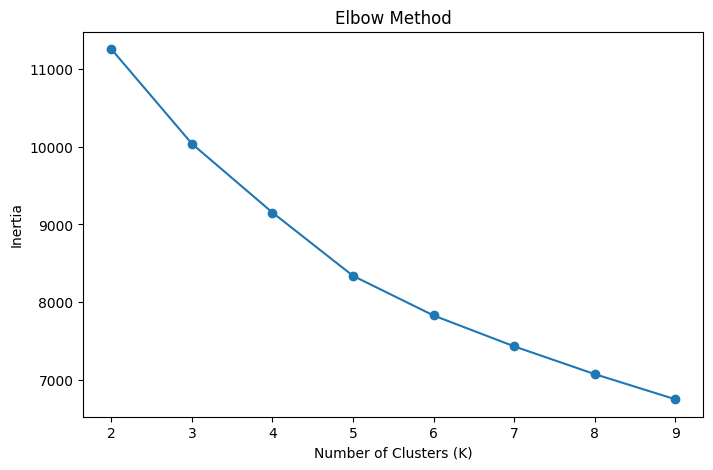

In [74]:


plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 10),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.savefig("../visualizations/elbow_method.png", dpi=300, bbox_inches="tight")
plt.savefig("../visualizations/elbow_method.png", dpi=300, bbox_inches="tight")



plt.show()

This is the elbow. Here the curve starts bending significantly. We are particularly interested in whether K = 4 makes sense because the PRD propses four segments:
1. Global Investors
2. First Time Buyers
3. Corporate Buyers
4. Luxury Investors

But we can't choose 4 just because the PRD says No.
We need to verify using Sillihouette Score

In [52]:
silhouette_scores = []

for k in range(2, 10):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(x)

    score = silhouette_score(x, labels)

    silhouette_scores.append(score)

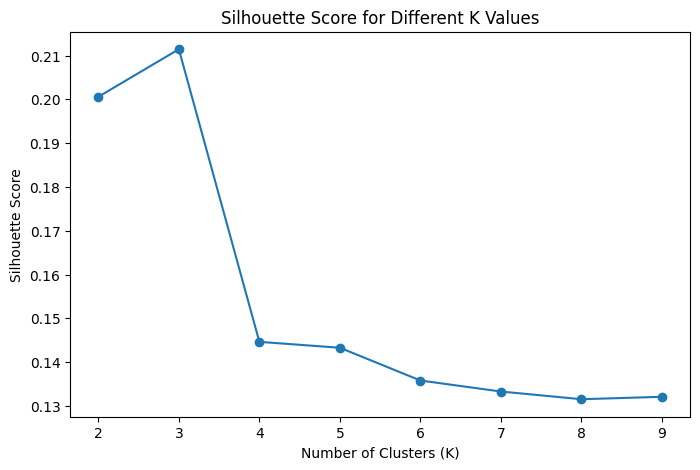

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 10),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')

plt.show()

In [76]:

%pip install plotly kaleido
import plotly.express as px

os.makedirs("../visualizations", exist_ok=True)

# 1. build the figure
fig = px.box(
    client_df,
    x="segment",
    y="total_spend",
    color="segment",
    title="Total Spend by Segment"
)

# 2. save it
fig.write_image("../visualizations/spend_by_segment.png", scale=3)


# 3. show it
fig.show()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
best_k = range(2, 10)[
    np.argmax(silhouette_scores)
]

print("Best K:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

Best K: 3
Best Silhouette Score: 0.21145352712869783


In [55]:
#Applying the K-Means
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

In [56]:
#Generating the cluster labels
client_df['cluster'] = final_kmeans.fit_predict(x)

In [57]:
client_df['cluster'].value_counts().sort_index()

cluster
0    662
1    638
2     51
3    649
Name: count, dtype: int64

Hierarchical Clustering

In [58]:
hierarchical = AgglomerativeClustering(
    n_clusters=4
)
hierarchical_labels = hierarchical.fit_predict(x)

#calculating its silhouette score
hierarchical_score = silhouette_score(x,hierarchical_labels)

print("Hierarchical Silhouette Score:",hierarchical_score)

Hierarchical Silhouette Score: 0.11626643182131699


Profiling the Clusters

In [59]:
numeric_cols = ["age", "satisfaction_score"]

# Convert string/object score column to numeric first
client_df["satisfaction_score"] = pd.to_numeric(
    client_df["satisfaction_score"],
    errors="coerce"
)

cluster_profile = (client_df.groupby("cluster")[numeric_cols].mean().round(2))

cluster_profile

,age,satisfaction_score
cluster,,
0,56.08,2.41
1,55.36,4.15
2,64.61,3.49
3,55.59,2.53


In [60]:
#analysing the acquisition purpose
pd.crosstab(
    client_df['cluster'],
    client_df['acquisition_purpose'],
    normalize='index'
).round(2)

acquisition_purpose,home,investment
cluster,,
0,0.66,0.34
1,0.72,0.28
2,0.65,0.35
3,0.70,0.30


In [61]:
#Analyzing the lone behaviour
pd.crosstab(
    client_df['cluster'],
    client_df['loan_applied'],
    normalize='index'
).round(2)

loan_applied,0,1
cluster,,
0,0.63,0.37
1,0.63,0.37
2,0.69,0.31
3,0.64,0.36


In [62]:
#Analyzing the client Type
pd.crosstab(
    client_df['cluster'],
    client_df['client_type'],
    normalize='index'
).round(2)

client_type,company,individual
cluster,,
0,0.04,0.96
1,0.05,0.95
2,0.04,0.96
3,0.06,0.94


In [63]:
#analyzing the geographic behaviour
# On the basis of Country
pd.crosstab(
    client_df['cluster'],
    client_df['country'],
    normalize='index'
).round(2)

country,australia,belgium,canada,denmark,france,germany,mexico,russia,uk,usa
cluster,,,,,,,,,,
0,0.03,0.02,0.05,0.00,0.03,0.03,0.02,0.02,0.05,0.75
1,0.01,0.03,0.04,0.01,0.02,0.02,0.02,0.01,0.05,0.79
2,0.00,0.02,0.02,0.00,0.02,0.02,0.00,0.00,0.06,0.86
3,0.02,0.02,0.04,0.01,0.03,0.03,0.02,0.02,0.05,0.76


In [64]:
#on the basis of region
pd.crosstab(
    client_df['cluster'],
    client_df['region'],
    normalize='index'
).round(2)

region,alberta,arizona,baja california,bavaria,berlin,british columbia,brittany,brussels,california,capital region,...,texas,utah,victoria,virginia,wales,wallonia,washington,western australia,wyoming,zealand
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.02,0.06,0.00,0.01,0.01,0.01,0.01,0.01,0.30,0.00,...,0.03,0.05,0.01,0.03,0.01,0.00,0.03,0.01,0.0,0.0
1,0.01,0.06,0.00,0.00,0.01,0.01,0.00,0.01,0.33,0.00,...,0.03,0.04,0.00,0.04,0.01,0.01,0.04,0.00,0.0,0.0
2,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.02,0.47,0.00,...,0.02,0.00,0.00,0.08,0.00,0.00,0.00,0.00,0.0,0.0
3,0.01,0.05,0.01,0.01,0.00,0.01,0.01,0.00,0.31,0.01,...,0.02,0.05,0.01,0.03,0.01,0.01,0.04,0.00,0.0,0.0


In [65]:
#Analyze the property behaviour

client_df.groupby('cluster')[
    [
        'units_bought',
        'total_spend',
        'avg_price',
        'avg_area'
    ]
].mean().round(2)


,units_bought,total_spend,avg_price,avg_area
cluster,,,,
0,3.42,965580.52,283513.94,945.74
1,3.75,1264156.21,338880.11,1122.40
2,7.29,2397660.05,330963.05,1094.89
3,3.51,1467988.18,421277.43,1382.05


In [66]:
#Giving Clusters meaningful names
cluster_names = {
    0: 'Corporate Buyers',
    1: 'First-Time Buyers',
    2: 'Luxury Investors',
    3: 'Global Investors'
}

In [67]:
client_df['segment'] = client_df['cluster'].map(
    cluster_names
)

In [68]:
#check the client on the basis of the clusters
client_df[
    ['client_id', 'cluster', 'segment']
].head()

,client_id,cluster,segment
0,c0001,1,First-Time Buyers
1,c0002,3,Global Investors
2,c0003,1,First-Time Buyers
3,c0004,2,Luxury Investors
4,c0005,2,Luxury Investors


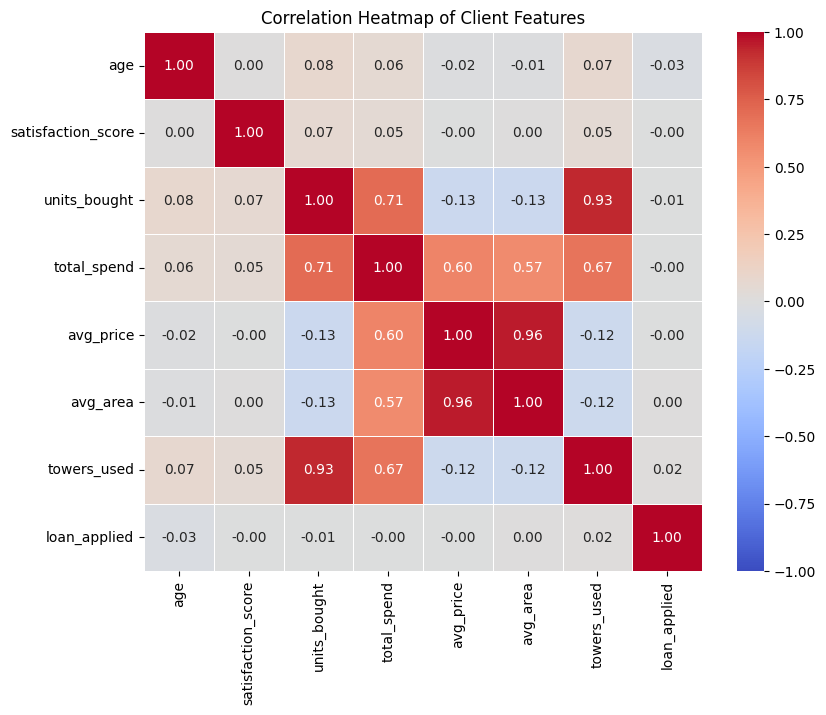

In [77]:
#Creating the Heat Map
num_cols = ["age", "satisfaction_score", "units_bought", "total_spend",
            "avg_price", "avg_area", "towers_used", "loan_applied"]

plt.figure(figsize=(9, 7))
sns.heatmap(client_df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap of Client Features")
plt.savefig("../visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Saving the Final Segmentation

In [69]:
final_data = client_df.copy()


In [70]:
client_df.to_csv(
    '../data/processed/client_segmentation.csv',
    index=False
)

In [71]:
import os


path = '../data/processed/client_segmentation.csv'

client_df.to_csv(path, index=False)

print("Saved successfully!")
print(os.path.abspath(path))

Saved successfully!
c:\Users\Chandan\Desktop\Financial-Analytics-Real-Estate\data\processed\client_segmentation.csv
